# 위험중립형 백테스팅

> **목표:** "오를 때 충분히 벌고, 내릴 때 확실히 피한다"
> - 목표 수익: 연 CAGR **5~10%**
> - 핵심 제약: MDD **-15% 이내** / MDD Duration **6개월 이내**

---

## 전략 구조

| 레이어 | 내용 |
|--------|------|
| 국면 판별 | MA20/60/120 정렬 + ADX 추세강도 → 4국면 |
| 전략 스위칭 | UPTREND: 골든크로스 / SIDEWAYS: 볼린저밴드 / DOWNTREND: 현금 |
| 포지션 관리 | 분할 매수 3단계 + 분할 매도 3단계 |
| 포트폴리오 | 5개 섹터 대표 종목 × 모멘텀 비례 배분 |
| 최적화 | Walk-Forward (12개월 학습 / 6개월 검증), metric=calmar_ratio |

---

## 성과 평가 기준

| 지표 | 기준 | 역할 |
|------|------|------|
| CAGR | 5~10% | 1차 관문. 미달 시 예금과 다를 바 없음 |
| MDD | -15% 이내 | 핵심. 전략의 존재 이유 |
| MDD Duration | 6개월 이내 | 실전 운용 가능성 |
| Calmar | 0.5 이상 | 하락 리스크 대비 수익 효율 |
| Sortino | 1.0 이상 | 하락 변동성 기준 효율 (샤프 대체) |

## 0. 환경 설정

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import vectorbt as vbt

# ── 위험중립형 설정 ───────────────────────────────────────────────────────────
from vbt_backtest.profiles import neutral

# ── 전략 ─────────────────────────────────────────────────────────────────────
from vbt_backtest.strategies.combined.ma_regime_strategy import (
    calc_regime, make_signals as regime_make_signals, REGIME_COLORS,
)
from vbt_backtest.strategies.combined.partial_auto_strategy import (
    make_signals as partial_make_signals,
    run_backtest as partial_run_backtest,
)

# ── 최적화 ────────────────────────────────────────────────────────────────────
from vbt_backtest.optimizer import walk_forward, ADX_PARAM_GRID, WF_TRAIN_MONTHS, WF_TEST_MONTHS

# ── 포트폴리오 ────────────────────────────────────────────────────────────────
from vbt_backtest.portfolio_backtest import (
    load_portfolio_data, build_size_df,
    run_portfolio_backtest, run_bh_portfolio, run_bh_single,
)

# ── 성과지표 & 시각화 ─────────────────────────────────────────────────────────
from vbt_backtest.metrics import build_metrics_table, calc_metrics
from vbt_backtest.plots.performance import (
    plot_equity_curves, plot_weight_heatmap,
    plot_contribution, plot_diversification, plot_yearly_returns,
)

print(f'수수료: {neutral.FEES:.2%} | 슬리피지: {neutral.SLIPPAGE:.2%}')
print(f'ADX 임계값: {neutral.ADX_THRESHOLD} | ADX 횡보: {neutral.ADX_SIDEWAYS}')
print(f'분할매수 비중: 1차={neutral.ENTRY1_SIZE:.0%} / 2차={neutral.ENTRY2_SIZE:.0%} / 횡보={neutral.ENTRY_RANGE_SIZE:.0%}')
print(f'분할매도 유지: 1차={neutral.EXIT1_SIZE:.0%} / 2차={neutral.EXIT2_SIZE:.0%}')

수수료: 0.15% | 슬리피지: 0.10%
ADX 임계값: 25.0 | ADX 횡보: 20.0
분할매수 비중: 1차=40% / 2차=70% / 횡보=30%
분할매도 유지: 1차=40% / 2차=10%


---
## 1. 데이터 로드

위험중립형 포트폴리오는 **5개 섹터 대표 종목**으로 구성한다.
단일 종목 집중의 변동성을 분산투자로 완화하는 것이 목적이다.

| 종목 | WICS 섹터 |
|------|-----------|
| 삼성전자 | IT (반도체) |
| SK하이닉스 | IT (메모리) |
| NAVER | 경기관련소비재 (인터넷) |
| 현대차 | 경기관련소비재 (자동차) |
| POSCO홀딩스 | 소재 (철강) |

In [2]:
TICKERS = {
    '삼성전자':    '005930.KS',
    'SK하이닉스':  '000660.KS',
    'NAVER':      '035420.KS',
    '현대차':      '005380.KS',
    'POSCO홀딩스': '005490.KS',
}
START = '2019-01-01'
END   = '2024-12-31'

data      = load_portfolio_data(TICKERS, START, END)
close_df  = data['close']
high_df   = data['high']
low_df    = data['low']
volume_df = data['volume']

NAMES = list(close_df.columns)
N     = len(NAMES)

print(f'기간: {close_df.index[0].date()} ~ {close_df.index[-1].date()}')
print(f'종목: {NAMES}')
close_df.tail(3)

기간: 2019-01-02 ~ 2024-12-30
종목: ['삼성전자', 'SK하이닉스', 'NAVER', '현대차', 'POSCO홀딩스']


Ticker,삼성전자,SK하이닉스,NAVER,현대차,POSCO홀딩스
Date,,,,,
2024-12-26,52005.328125,168028.671875,196856.390625,203067.656250,245475.078125
2024-12-27,52457.621094,172375.125000,194689.875000,200733.546875,243077.843750
2024-12-30,51969.183594,171782.421875,195871.609375,197932.625000,243077.843750


---
## 2. 단일 종목 — 시장 국면 판별

삼성전자를 예시로 4국면 판별 결과를 확인한다.

**판별 우선순위:** SIDEWAYS → UPTREND → DOWNTREND → TRANSITION

```
SIDEWAYS   : ADX < adx_sideways
UPTREND    : MA20 > MA60 > MA120  AND  ADX > adx_threshold
DOWNTREND  : MA20 < MA60 < MA120  AND  ADX > adx_threshold
TRANSITION : 위 3가지 미해당
```

In [3]:
name  = '삼성전자'
close = close_df[name]
high  = high_df[name]
low   = low_df[name]

regime, masks, adx_df = calc_regime(
    close, high, low,
    adx_threshold=neutral.ADX_THRESHOLD,
    adx_sideways=neutral.ADX_SIDEWAYS,
)

print('=== 국면별 거래일 수 ===')
counts = regime.value_counts()
total  = len(regime.dropna())
for r, c in counts.items():
    print(f'  {r:12s}: {c:4d}일  ({c/total:.1%})')

=== 국면별 거래일 수 ===
  SIDEWAYS    :  692일  (46.9%)
  TRANSITION  :  425일  (28.8%)
  UPTREND     :  257일  (17.4%)
  DOWNTREND   :  101일  (6.8%)


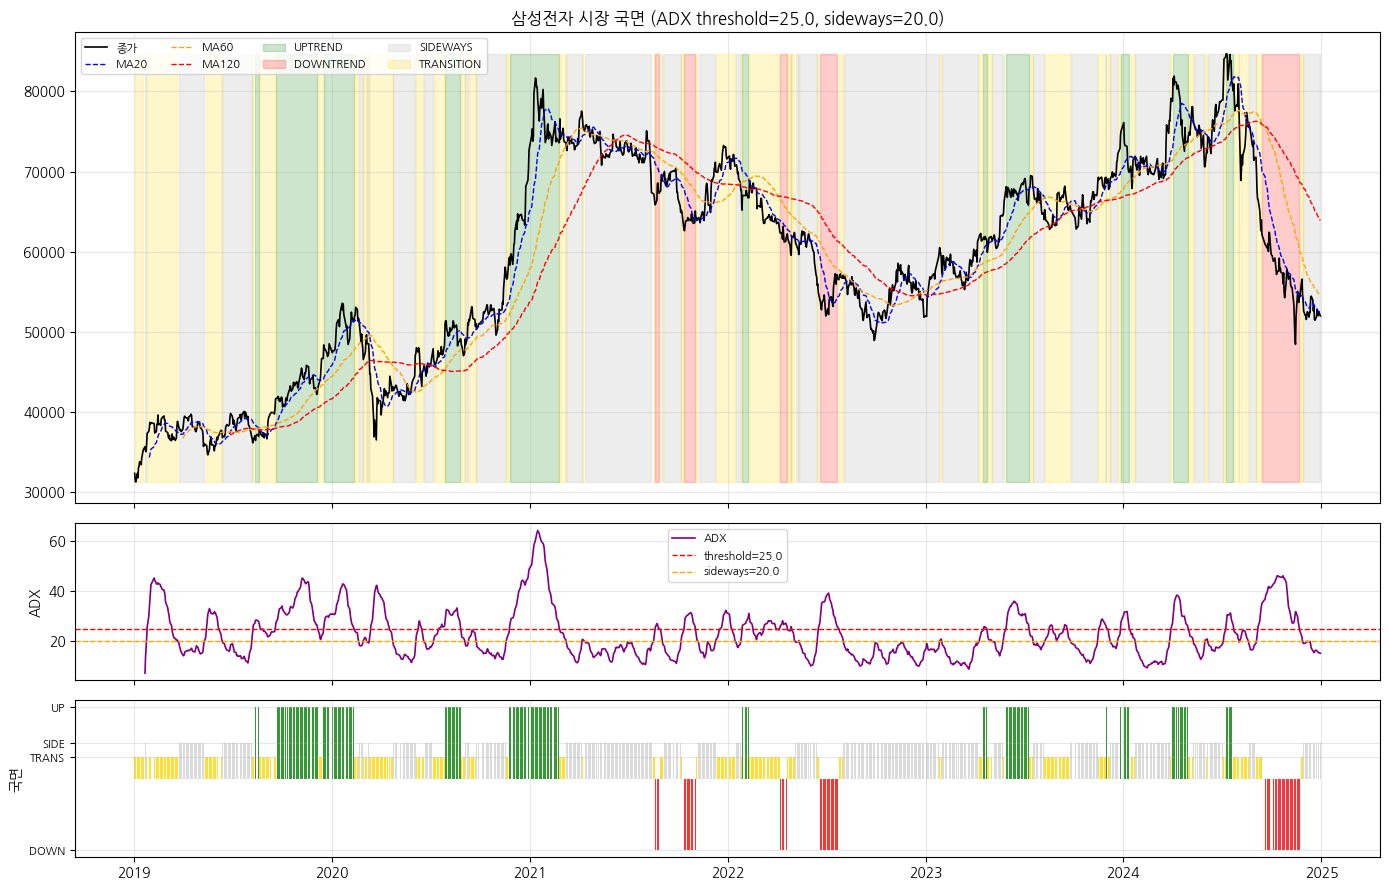

In [4]:
# 국면 배경색 시각화
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1, 1]})

# 종가 + MA
axes[0].plot(close, color='black', lw=1.2, label='종가')
axes[0].plot(masks['ma_s'], color='blue',   lw=1.0, ls='--', label='MA20')
axes[0].plot(masks['ma_m'], color='orange', lw=1.0, ls='--', label='MA60')
axes[0].plot(close.rolling(120).mean(), color='red', lw=1.0, ls='--', label='MA120')
for r, (color, alpha) in REGIME_COLORS.items():
    mask = regime == r
    axes[0].fill_between(close.index, close.min(), close.max(),
                         where=mask, color=color, alpha=alpha, label=r)
axes[0].set_title(f'{name} 시장 국면 (ADX threshold={neutral.ADX_THRESHOLD}, sideways={neutral.ADX_SIDEWAYS})')
axes[0].legend(fontsize=8, ncol=4)
axes[0].grid(True, alpha=0.3)

# ADX
axes[1].plot(masks['adx'], color='purple', lw=1.2, label='ADX')
axes[1].axhline(neutral.ADX_THRESHOLD, color='red',    lw=1, ls='--', label=f'threshold={neutral.ADX_THRESHOLD}')
axes[1].axhline(neutral.ADX_SIDEWAYS,  color='orange', lw=1, ls='--', label=f'sideways={neutral.ADX_SIDEWAYS}')
axes[1].set_ylabel('ADX')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# 국면 bar
regime_num = regime.map({'UPTREND': 1, 'SIDEWAYS': 0.5, 'TRANSITION': 0.3, 'DOWNTREND': -1})
colors_bar = regime.map({k: v[0] for k, v in REGIME_COLORS.items()})
axes[2].bar(regime.index, regime_num, color=colors_bar, width=1, alpha=0.8)
axes[2].set_ylabel('국면')
axes[2].set_yticks([1, 0.5, 0.3, -1])
axes[2].set_yticklabels(['UP', 'SIDE', 'TRANS', 'DOWN'], fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. 단일 종목 — 분할 매수/매도 신호

**분할 매수 3단계:**

| 단계 | 조건 | 목표 비중 |
|------|------|-----------|
| 1차 | UPTREND + 골든크로스 | 40% |
| 2차 | UPTREND + MA20 지지 재확인 (60일 이내) | 70% |
| 횡보 | SIDEWAYS + 볼린저밴드 하단 | 30% |

**분할 매도 3단계 (청산 우선순위: DOWNTREND > 데드크로스 > TRANSITION > BB상단):**

| 단계 | 조건 | 유지 비중 |
|------|------|-----------|
| 1차 익절 | UPTREND → TRANSITION 전환 첫날 | 40% |
| 2차 청산 | 데드크로스 | 10% |
| 전량 청산 | DOWNTREND 진입 | 0% |

In [5]:
entries, exits, size_series, detail = partial_make_signals(
    close, high, low,
    adx_threshold=neutral.ADX_THRESHOLD,
    adx_sideways=neutral.ADX_SIDEWAYS,
    entry1_size=neutral.ENTRY1_SIZE,
    entry2_size=neutral.ENTRY2_SIZE,
    entry_range_size=neutral.ENTRY_RANGE_SIZE,
    exit1_size=neutral.EXIT1_SIZE,
    exit2_size=neutral.EXIT2_SIZE,
    recent_window=neutral.RECENT_WINDOW,
)

print('=== 신호 횟수 ===')
print(f'  1차 매수 (골든크로스):     {detail["entry1"].sum():3d}회')
print(f'  2차 매수 (MA20 지지):      {detail["entry2"].sum():3d}회')
print(f'  횡보 매수 (BB 하단):       {detail["entry_range"].sum():3d}회')
print(f'  1차 익절 (TRANSITION):     {detail["transition_from_up"].sum():3d}회')
print(f'  2차 청산 (데드크로스):     {detail["dead_cross"].sum():3d}회')
print(f'  횡보 청산 (BB 상단):       {detail["bb_exit_sideways"].sum():3d}회')

=== 신호 횟수 ===
  1차 매수 (골든크로스):       1회
  2차 매수 (MA20 지지):        4회
  횡보 매수 (BB 하단):         8회
  1차 익절 (TRANSITION):      12회
  2차 청산 (데드크로스):      15회
  횡보 청산 (BB 상단):        13회


---
## 4. 단일 종목 — 백테스트 성과

In [6]:
pf_single    = partial_run_backtest(
    close, high, low,
    adx_threshold=neutral.ADX_THRESHOLD,
    adx_sideways=neutral.ADX_SIDEWAYS,
    fees=neutral.FEES, slippage=neutral.SLIPPAGE,
)
pf_bh_single = run_bh_single(close, fees=neutral.FEES, slippage=neutral.SLIPPAGE)

n_years  = (close.index[-1] - close.index[0]).days / 365.25
row_strat = calc_metrics(pf_single.value(),    f'{name} 위험중립형', n_years)
row_bh    = calc_metrics(pf_bh_single.value(), f'{name} Buy&Hold',  n_years)
pd.DataFrame([row_bh, row_strat]).set_index('전략')

,총 수익률,CAGR,연간 변동성,샤프비율,MDD,Calmar
전략,,,,,,
삼성전자 Buy&Hold,60.51%,8.22%,26.27%,0.44,-42.85%,0.19
삼성전자 위험중립형,19.23%,2.98%,6.37%,0.50,-9.92%,0.30


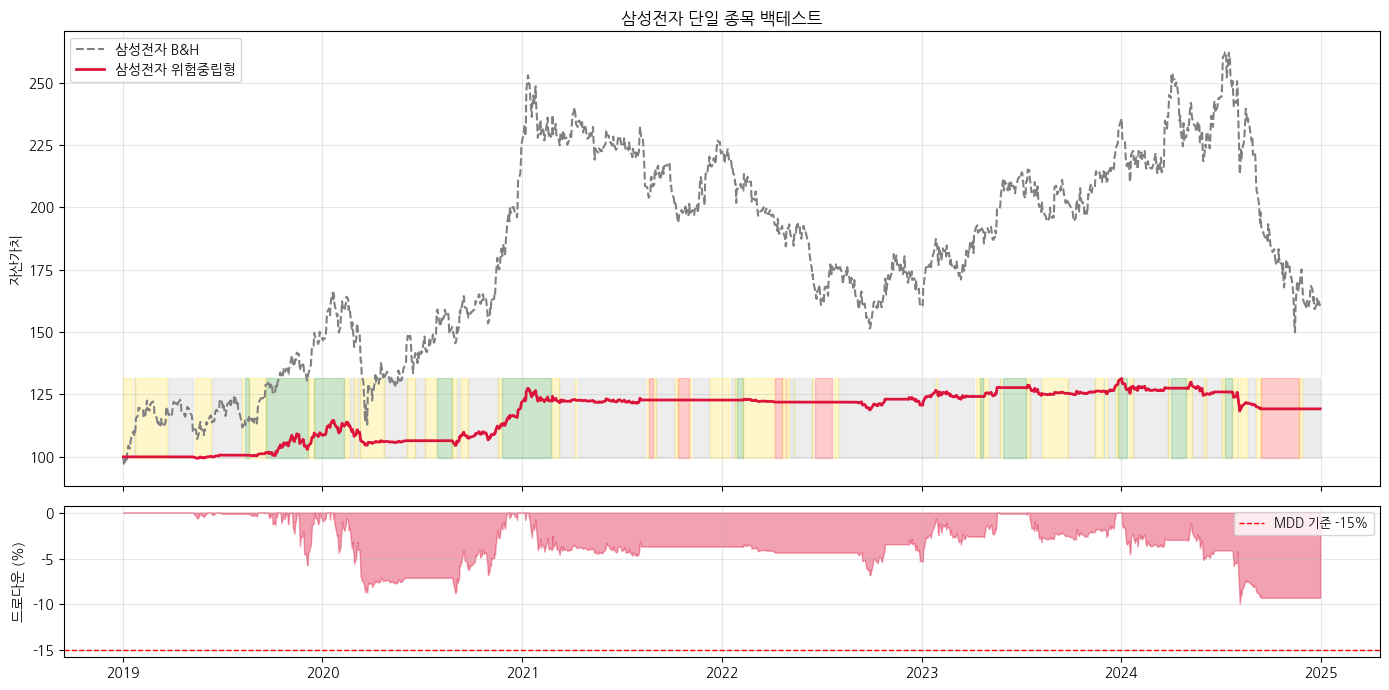

In [7]:
# 단일 종목 자산곡선 비교
val_s  = pf_single.value()
val_bh = pf_bh_single.value() / pf_bh_single.value().iloc[0] * val_s.iloc[0]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(val_bh, color='gray',   lw=1.5, ls='--', label=f'{name} B&H')
axes[0].plot(val_s,  color='crimson', lw=2,   ls='-',  label=f'{name} 위험중립형')
for r, (color, alpha) in REGIME_COLORS.items():
    axes[0].fill_between(close.index, val_s.min(), val_s.max(),
                         where=(regime == r), color=color, alpha=alpha)
axes[0].set_title(f'{name} 단일 종목 백테스트')
axes[0].set_ylabel('자산가치')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

dd = (val_s / val_s.cummax() - 1) * 100
axes[1].fill_between(dd.index, 0, dd, color='crimson', alpha=0.4)
axes[1].axhline(-15, color='red', lw=1, ls='--', label='MDD 기준 -15%')
axes[1].set_ylabel('드로다운 (%)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Walk-Forward 최적화

그리드 서치는 과거 데이터에 과최적화될 위험이 있다.
Walk-Forward는 **미래 데이터를 학습에 사용하지 않고** 6개월마다 파라미터를 재탐색한다.

```
[12개월 학습] → 최적 adx_threshold 탐색
                    ↓
            [6개월 검증] → 해당 파라미터로 실전 시뮬레이션
                                ↓
                        [다음 12개월 학습] → 재탐색 ...
```

**최적화 metric:** `calmar_ratio` (위험중립형 = MDD 최소화 목표)

In [8]:
print(f'탐색 범위: {ADX_PARAM_GRID}')
print(f'학습 구간: {WF_TRAIN_MONTHS}개월 / 검증 구간: {WF_TEST_MONTHS}개월')
print('최적화 기준: calmar_ratio (위험중립형 권장)')

탐색 범위: {'adx_threshold': [15, 20, 25, 30], 'adx_sideways': [10, 15, 20]}
학습 구간: 12개월 / 검증 구간: 6개월
최적화 기준: calmar_ratio (위험중립형 권장)


In [9]:
wf_result = walk_forward(
    close, partial_run_backtest,
    param_grid=ADX_PARAM_GRID,
    train_months=WF_TRAIN_MONTHS,
    test_months=WF_TEST_MONTHS,
    metric='calmar_ratio',
    fees=neutral.FEES,
    slippage=neutral.SLIPPAGE,
    high=high, low=low,
)

print(f'총 윈도우 수: {wf_result["n_windows"]}')
print()
print(f'{"학습 기간":^25} {"검증 기간":^25} {"최적 파라미터":^35} {"점수":>8}')
print('-' * 100)
for w in wf_result['windows']:
    train = f"{w['train_start'].date()} ~ {w['train_end'].date()}"
    test  = f"{w['test_start'].date()} ~ {w['test_end'].date()}"
    print(f'{train:^25} {test:^25} {str(w["best_params"]):^35} {w["best_score"]:>8.3f}')

총 윈도우 수: 9

          학습 기간                     검증 기간                         최적 파라미터                     점수
----------------------------------------------------------------------------------------------------
 2019-01-02 ~ 2020-01-02   2020-01-02 ~ 2020-07-01  {'adx_threshold': 30, 'adx_sideways': 20}    4.501
 2019-07-02 ~ 2020-07-02   2020-07-02 ~ 2020-12-30  {'adx_threshold': 15, 'adx_sideways': 10}   -0.285
 2020-01-02 ~ 2021-01-02   2021-01-04 ~ 2021-07-01  {'adx_threshold': 30, 'adx_sideways': 10}   10.145
 2020-07-02 ~ 2021-07-02   2021-07-02 ~ 2021-12-30  {'adx_threshold': 15, 'adx_sideways': 20}    4.591
 2021-01-02 ~ 2022-01-02   2022-01-04 ~ 2022-07-01  {'adx_threshold': 15, 'adx_sideways': 10}    1.378
 2021-07-02 ~ 2022-07-02   2022-07-04 ~ 2022-12-29  {'adx_threshold': 15, 'adx_sideways': 10}   -0.946
 2022-01-02 ~ 2023-01-02   2023-01-02 ~ 2023-06-30  {'adx_threshold': 20, 'adx_sideways': 10}   -0.252
 2022-07-02 ~ 2023-07-02   2023-07-03 ~ 2023-12-28  {'adx_threshold':

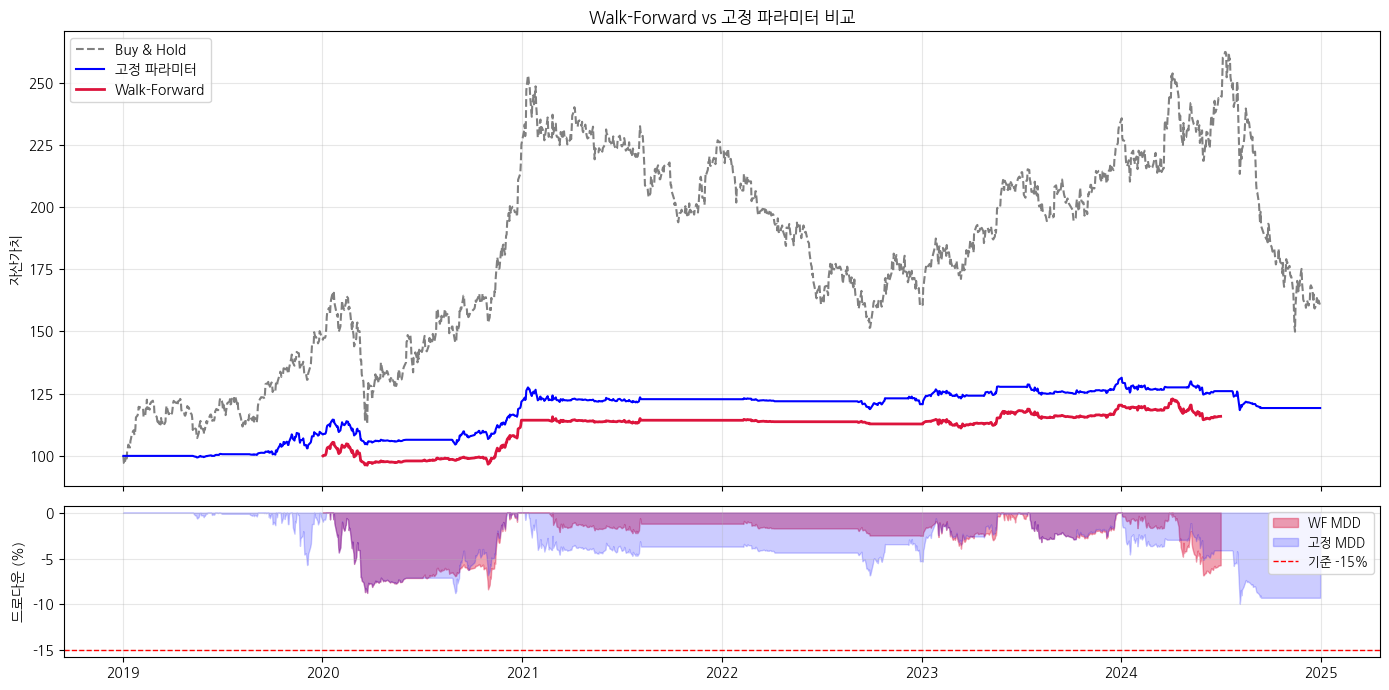

In [10]:
# Walk-Forward vs 고정 파라미터 자산곡선 비교
equity_wf = wf_result['equity_curve']

if len(equity_wf) > 0:
    init = val_s.iloc[0]
    wf_norm = equity_wf / equity_wf.iloc[0] * init
    bh_norm = pf_bh_single.value() / pf_bh_single.value().iloc[0] * init

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                             gridspec_kw={'height_ratios': [3, 1]})

    axes[0].plot(bh_norm,  color='gray',   lw=1.5, ls='--', label='Buy & Hold')
    axes[0].plot(val_s,    color='blue',   lw=1.5, ls='-',  label='고정 파라미터')
    axes[0].plot(wf_norm,  color='crimson', lw=2,  ls='-',  label='Walk-Forward')
    axes[0].set_title('Walk-Forward vs 고정 파라미터 비교')
    axes[0].set_ylabel('자산가치')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    dd_wf = (wf_norm / wf_norm.cummax() - 1) * 100
    dd_fixed = (val_s / val_s.cummax() - 1) * 100
    axes[1].fill_between(dd_wf.index,    0, dd_wf,    color='crimson', alpha=0.4, label='WF MDD')
    axes[1].fill_between(dd_fixed.index, 0, dd_fixed, color='blue',    alpha=0.2, label='고정 MDD')
    axes[1].axhline(-15, color='red', lw=1, ls='--', label='기준 -15%')
    axes[1].set_ylabel('드로다운 (%)')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('Walk-Forward 검증 구간 데이터가 부족합니다.')

---
## 6. 멀티종목 포트폴리오

5개 종목에 대해 위험중립형 전략을 동시 적용하고,
**국면별 모멘텀 비례 배분**으로 강한 종목에 더 많은 자본을 배치한다.

| 국면 | 모멘텀 윈도우 | 이유 |
|------|--------------|------|
| UPTREND | 126일 (6개월) | 추세가 길게 이어지므로 장기 모멘텀 신뢰도 높음 |
| TRANSITION | 63일 (3개월) | 방향 불확실, 중기 모멘텀 사용 |
| SIDEWAYS | 21일 (1개월) | 단기 등락 반복, 빠른 반응 필요 |

In [11]:
size_df, signal_counts = build_size_df(
    close_df, high_df, low_df, volume_df,
    adx_threshold=neutral.ADX_THRESHOLD,
    adx_sideways=neutral.ADX_SIDEWAYS,
    min_momentum=neutral.MIN_MOMENTUM,
)

print('=== 종목별 신호 횟수 ===')
pd.DataFrame(signal_counts).T

=== 종목별 신호 횟수 ===


,진입 횟수,1차 익절,2차 청산
삼성전자,13,12,15
SK하이닉스,14,11,9
NAVER,11,11,13
현대차,18,9,16
POSCO홀딩스,22,13,18


In [12]:
pf_port   = run_portfolio_backtest(close_df, size_df, fees=neutral.FEES, slippage=neutral.SLIPPAGE)
pf_bh_eq  = run_bh_portfolio(close_df, fees=neutral.FEES, slippage=neutral.SLIPPAGE)
pf_bh_ss  = run_bh_single(close_df['삼성전자'], fees=neutral.FEES, slippage=neutral.SLIPPAGE)

print('포트폴리오 백테스트 완료')

포트폴리오 백테스트 완료


---
## 7. 성과 평가

### 7-1. 성과 비교 테이블

In [13]:
build_metrics_table(pf_port, pf_bh_eq, pf_bh_ss, close_df, bh_ss_name='삼성전자')

,총 수익률,CAGR,연간 변동성,샤프비율,MDD,Calmar
전략,,,,,,
삼성전자 단독 B&H,60.51%,8.22%,26.27%,0.44,-42.85%,0.19
5종목 균등 B&H,99.21%,12.19%,24.03%,0.61,-39.20%,0.31
★ 09번 포트폴리오,22.96%,3.51%,18.54%,0.28,-31.24%,0.11
삼성전자 단독 B&H,60.91%,8.26%,26.27%,0.44,-42.85%,0.19
SK하이닉스 단독 B&H,205.19%,20.46%,38.86%,0.68,-48.20%,0.42
NAVER 단독 B&H,71.16%,9.38%,35.04%,0.44,-65.45%,0.14
현대차 단독 B&H,124.62%,14.46%,34.47%,0.57,-52.59%,0.27
POSCO홀딩스 단독 B&H,33.35%,4.92%,37.24%,0.32,-60.31%,0.08


### 7-2. MDD Duration · MDD 지속 기간

위험중립형 기준: **6개월(약 126거래일) 이내**

In [14]:
def calc_mdd_duration(equity: pd.Series) -> int:
    """드로다운 상태의 최장 연속 거래일 수 계산"""
    in_dd = (equity / equity.cummax() - 1) < 0
    max_dur = current = 0
    for d in in_dd:
        current = current + 1 if d else 0
        max_dur = max(max_dur, current)
    return max_dur

LIMIT_DAYS = 126  # 위험중립형 기준: 6개월

targets = {
    '삼성전자 B&H':      pf_bh_ss.value(),
    f'{N}종목 균등 B&H': pf_bh_eq.value(),
    '★ 위험중립형 포트': pf_port.value(),
}

print(f'MDD Duration 기준: {LIMIT_DAYS}거래일 이내 (약 6개월)\n')
for label, eq in targets.items():
    dur  = calc_mdd_duration(eq)
    flag = '✅ 통과' if dur <= LIMIT_DAYS else '❌ 초과'
    print(f'  {label:20s}: {dur:4d}거래일  {flag}')

MDD Duration 기준: 126거래일 이내 (약 6개월)

  삼성전자 B&H            :  795거래일  ❌ 초과
  5종목 균등 B&H          :  667거래일  ❌ 초과
  ★ 위험중립형 포트          :  758거래일  ❌ 초과


### 7-3. Sortino 비율 · 하락 변동성 기준 효율

위험중립형 기준: **1.0 이상** (샤프비율 대체 지표)

In [15]:
def calc_sortino(equity: pd.Series) -> float:
    """하락 변동성만 리스크로 처리한 Sortino 비율"""
    dr = equity.pct_change().dropna()
    downside_std = dr[dr < 0].std() * np.sqrt(252)
    return dr.mean() * 252 / downside_std if downside_std > 0 else np.nan

LIMIT_SORTINO = 1.0

print(f'Sortino 비율 기준: {LIMIT_SORTINO:.1f} 이상\n')
for label, eq in targets.items():
    s    = calc_sortino(eq)
    flag = '✅ 통과' if (not np.isnan(s) and s >= LIMIT_SORTINO) else '❌ 미달'
    print(f'  {label:20s}: {s:6.3f}  {flag}')

Sortino 비율 기준: 1.0 이상

  삼성전자 B&H            :  0.716  ❌ 미달
  5종목 균등 B&H          :  0.934  ❌ 미달
  ★ 위험중립형 포트          :  0.362  ❌ 미달


### 7-4. 위험중립형 평가 종합

In [16]:
eq = pf_port.value()
n_years = (eq.index[-1] - eq.index[0]).days / 365.25

cagr    = (eq.iloc[-1] / eq.iloc[0]) ** (1 / n_years) - 1
mdd     = (eq / eq.cummax() - 1).min()
calmar  = cagr / abs(mdd) if mdd < 0 else np.nan
sortino = calc_sortino(eq)
dur     = calc_mdd_duration(eq)

checks = {
    'CAGR':         (cagr,         0.05, 0.10, '%',  '5~10%'),
    'MDD':          (abs(mdd),     0,    0.15, '%',  '-15% 이내'),
    'MDD Duration': (dur,          0,    126,  '일', '126거래일 이내'),
    'Calmar':       (calmar,       0.5,  None, '',   '0.5 이상'),
    'Sortino':      (sortino,      1.0,  None, '',   '1.0 이상'),
}

print('=' * 55)
print('  위험중립형 전략 평가 결과')
print('=' * 55)
for metric, (val, lo, hi, unit, crit) in checks.items():
    if unit == '%':
        display = f'{val:.1%}'
    else:
        display = f'{val:.2f}'

    if metric == 'CAGR':
        ok = lo <= val <= hi
    elif metric == 'MDD':
        ok = val <= hi
    elif metric == 'MDD Duration':
        ok = val <= hi
    else:
        ok = (not np.isnan(val)) and val >= lo

    flag = '✅' if ok else '❌'
    print(f'  {flag} {metric:14s}: {display:>8}  (기준: {crit})')
print('=' * 55)

  위험중립형 전략 평가 결과
  ❌ CAGR          :     3.5%  (기준: 5~10%)
  ❌ MDD           :    31.2%  (기준: -15% 이내)
  ❌ MDD Duration  :   758.00  (기준: 126거래일 이내)
  ❌ Calmar        :     0.11  (기준: 0.5 이상)
  ❌ Sortino       :     0.36  (기준: 1.0 이상)


---
## 8. 시각화

### 8-1. 자산 곡선 비교

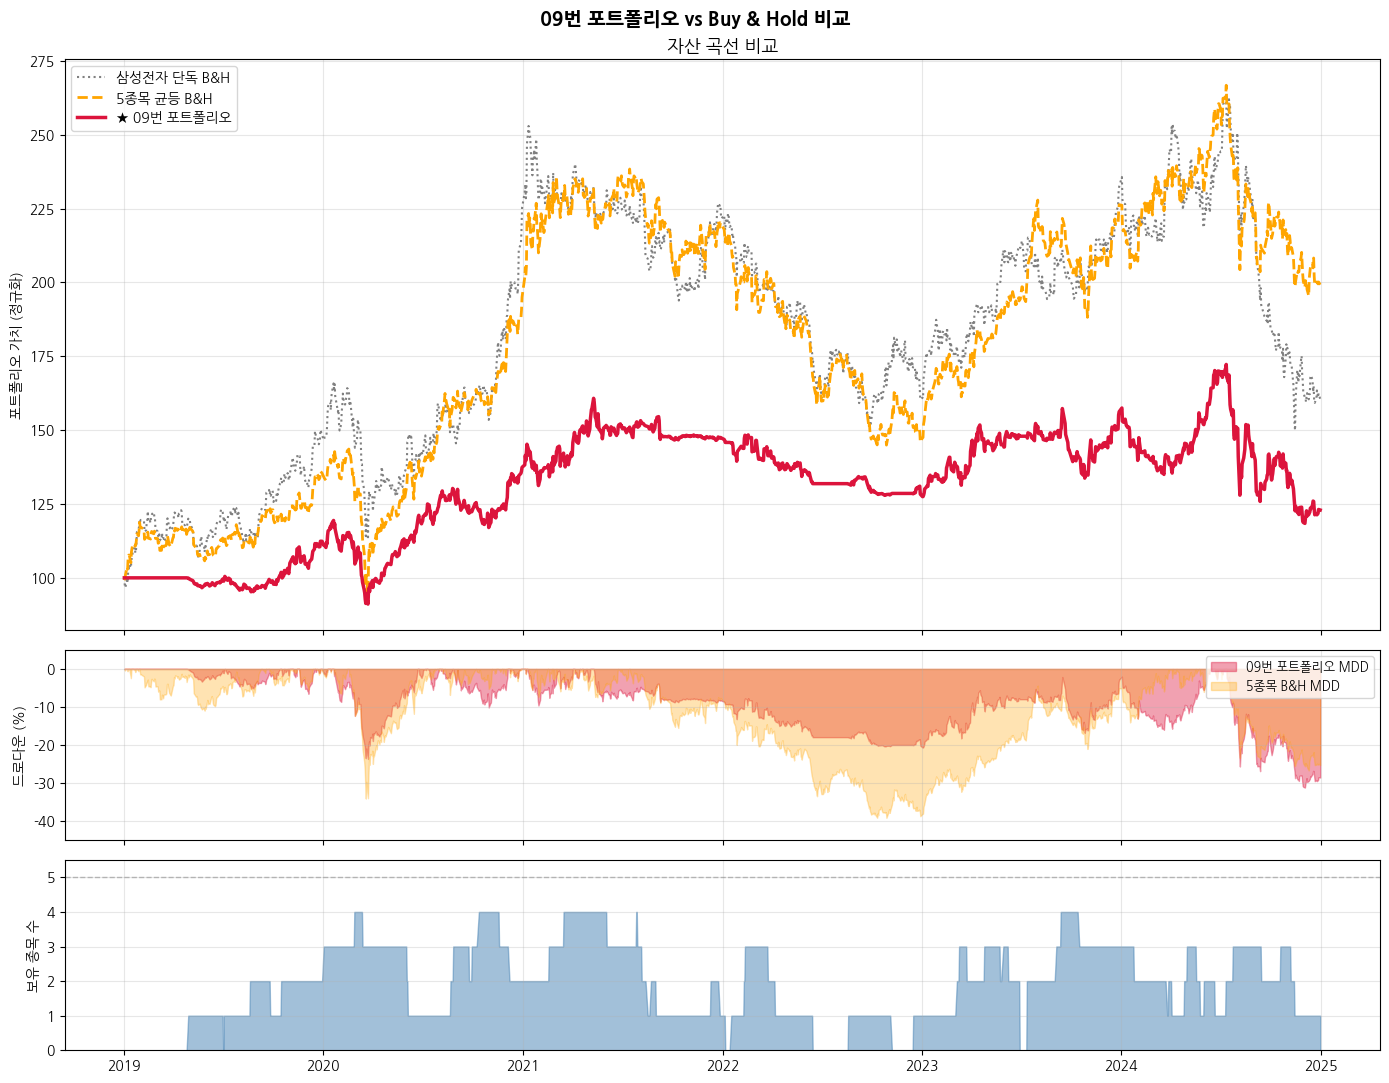

In [17]:
plot_equity_curves(pf_port, pf_bh_eq, pf_bh_ss, NAMES, N)

### 8-2. 월별 보유 비중 히트맵

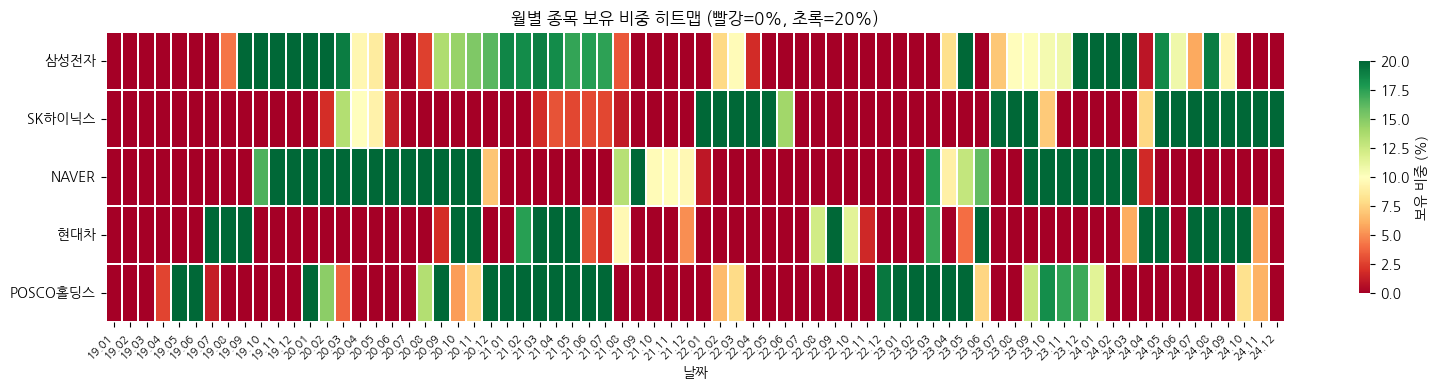


=== 종목별 평균 포지션 비중 ===
  삼성전자      : 11.7%  (최대 71.4%)
  SK하이닉스    : 8.8%  (최대 45.3%)
  NAVER     : 12.5%  (최대 50.1%)
  현대차       : 9.3%  (최대 47.1%)
  POSCO홀딩스  : 11.7%  (최대 49.8%)


In [18]:
plot_weight_heatmap(pf_port, NAMES)

### 8-3. 종목별 기여도

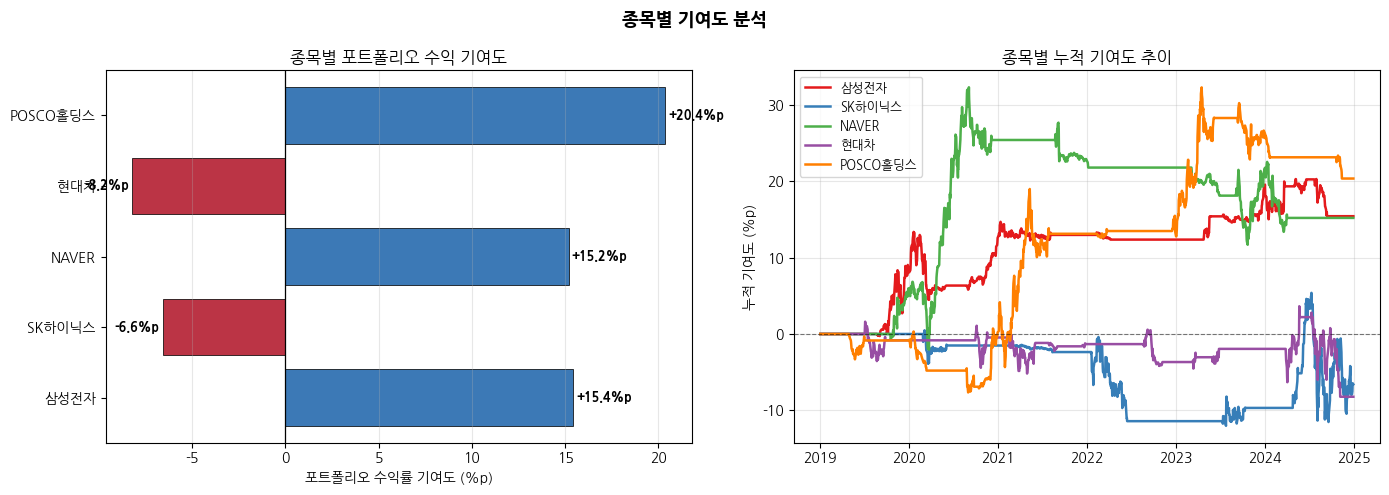


=== 종목별 기여도 순위 ===
  POSCO홀딩스  : +20.37%p
  삼성전자      : +15.44%p
  NAVER     : +15.21%p
  SK하이닉스    : -6.60%p
  현대차       : -8.22%p


In [19]:
plot_contribution(pf_port, close_df, NAMES)

### 8-4. 분산투자 효과

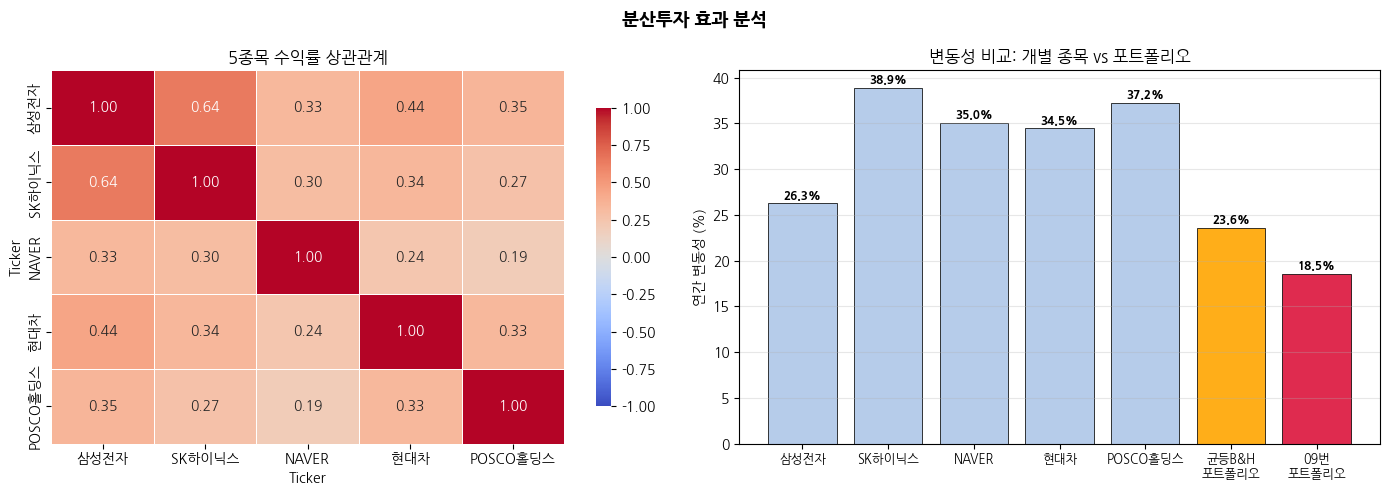


=== 분산투자 효과 ===
개별 종목 평균 변동성: 34.4%
균등 B&H 포트폴리오:  23.6%  (개별 대비 69%)
09번 포트폴리오:       18.5%  (개별 대비 54%)


In [20]:
plot_diversification(pf_port, pf_bh_eq, close_df, NAMES)

### 8-5. 연도별 수익률 비교

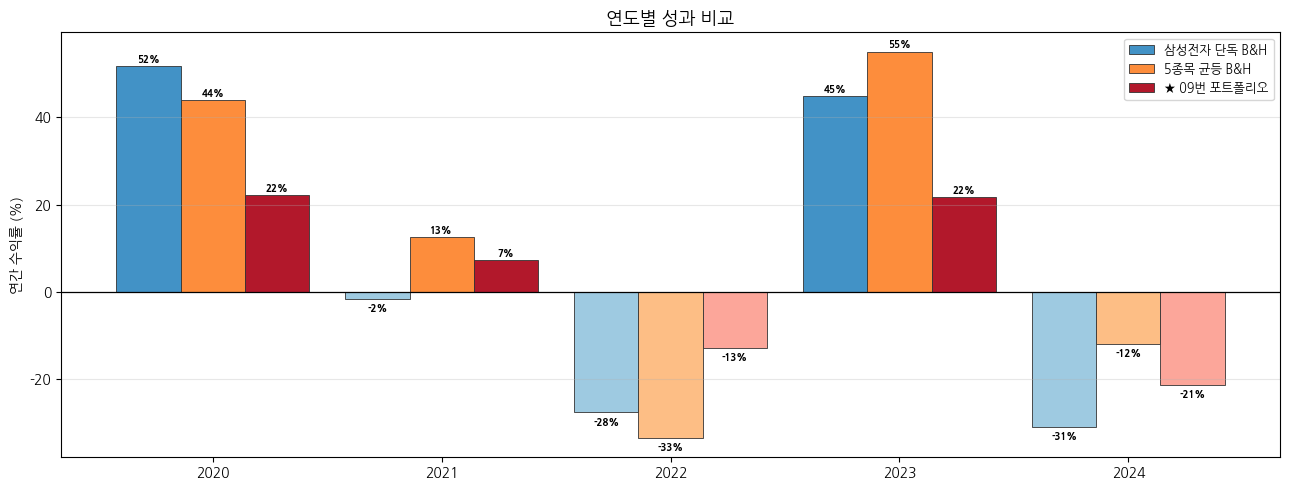

In [21]:
plot_yearly_returns(pf_port, pf_bh_eq, pf_bh_ss, bh_ss_name='삼성전자', n=N)